In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import MakePressures as MkP
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import time_utils as tuti
from Utils import numerical_utils as nuti

import analysis_utils as auti
import file_utils as futi
import event_utils as euti


#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# for smoothing , nonlienar colors ...
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers

# Some other useful packages 
import importlib
from pathlib import Path


importlib.reload( auti )
importlib.reload( futi )
importlib.reload( euti )

Rdair=Co.Rdair()


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


In [2]:
# This allow both dict.key and dict['key'] syntax
class AttrDict(dict):
    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")

    def __setattr__(self, key, value):
        self[key] = value

    def __delattr__(self, key):
        try:
            del self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")



In [3]:
%%time
importlib.reload( futi )
nsteps=None
start_date=None
#super_lat_range = [-90.,90.]  #[-85,-30]
super_lat_range = [-80.,-30.]  #[-85,-30]
#super_lat_range = [30.,80.] # Northern Summer!!!!!!!!!!
#case, process_ncdata, start_date, nsteps = 'c153_topfix_ne240pg3_FMTHIST_xic_x02'   , False #, [2004,7,15,0], 248
#case, process_ncdata, start_date, nsteps = 'c153_topfix_ne240pg3_FMTHIST_xic_x03'   , False #, [2007,7,15,0], 248
#case, process_ncdata, start_date, nsteps = 'c153_topfix_ne240pg3_FMTHIST_xic_x03'   , False #, [2007,8,15,0], 124
case, process_ncdata  = 'cam77_dyamond1_prod1'    , False
#case, process_ncdata  = 'c124_dyamond1_prod2'    , False
#case , process_ncdata = 'xy-rdg-mm-front'    , True
#nsteps=8
A = futi.read_case( case=case, nsteps=nsteps, start_date=start_date , super_lat_range=super_lat_range ) # , nsteps = 31*8 )

time, zlev, lat, lon = A.time, A.zlev, A.lat, A.lon



  nsteps=247 
/glade/derecho/scratch/juliob/archive/cam77_dyamond1_prod1/atm/hist/DynVars_dyamond_fv1x1.2016-08-01-10800.nc /glade/derecho/scratch/juliob/archive/cam77_dyamond1_prod1/atm/hist/DynVars_dyamond_fv1x1.2016-08-31-75600.nc
 Dataset opened  , dtype of U,V float32 float32 
 Dataset opened  trimmed. -79.63 to -30.63 
Read subsetted X w open_mfdata_set  139.4114 seconds
extracted upwp,...U,V,T etc  73.6664 seconds
Vorticity calc  2.1602 seconds
rho geopht pint ... calc  28.2733 seconds
rho calc ... epwp  2.2296 seconds
(247, 58, 53, 288)
(247, 58, 53, 288)
(247, 58, 53, 288)
(247, 58, 53, 288)
tilting calc  2.7841 seconds
this is Sphere_grad_vec in numerical_utils in HiRes_ana
dlat has been adjusted to account for FUCKED UP CRAPPY fv1x1 SCRIP FILE IN CESMDATA INPUTs!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 
frontogenesis calc  8.1552 seconds
CPU times: user 47 s, sys: 42.6 s, total: 1min 29s
Wall time: 4min 34s


In [4]:
"""
angll=A.angll[0,:,:] 
#plt.ylim(-360,360 )

levels = np.linspace(0, 180, 16)


import matplotlib.colors as mcolors

fig,ax=plt.subplots()
norm = mcolors.BoundaryNorm(levels, ncolors=256)

pcm = ax.pcolormesh(lon, lat, angll,
                    cmap='viridis',
                    norm=norm,
                    shading='auto')
cbar.set_ticks(np.linspace(0, 180, 6))  # e.g., 0,36,...,180



#--- define bins ---
levels = np.linspace(0, 180, 16)   # 15 bins → 16 edges
norm = mcolors.BoundaryNorm(levels, ncolors=256, clip=True)

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(lon, lat, angll,
                    cmap='viridis',
                    norm=norm,
                    shading='auto')

# --- colorbar ---
cbar = plt.colorbar(pcm, ax=ax, boundaries=levels)
cbar.set_label('Your Variable')

# optional: fewer ticks (cleaner)
cbar.set_ticks(np.linspace(0, 180, 6))  # 0,36,...,180
ax.set_xlim(250,350)
ax.set_ylim(-70,-30)

# --- labels ---
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('15-bin pcolormesh (0–180)')
"""

## Skipping


"\nangll=A.angll[0,:,:] \n#plt.ylim(-360,360 )\n\nlevels = np.linspace(0, 180, 16)\n\n\nimport matplotlib.colors as mcolors\n\nfig,ax=plt.subplots()\nnorm = mcolors.BoundaryNorm(levels, ncolors=256)\n\npcm = ax.pcolormesh(lon, lat, angll,\n                    cmap='viridis',\n                    norm=norm,\n                    shading='auto')\ncbar.set_ticks(np.linspace(0, 180, 6))  # e.g., 0,36,...,180\n\n\n\n#--- define bins ---\nlevels = np.linspace(0, 180, 16)   # 15 bins → 16 edges\nnorm = mcolors.BoundaryNorm(levels, ncolors=256, clip=True)\n\n# --- plot ---\nfig, ax = plt.subplots(figsize=(7, 5))\n\npcm = ax.pcolormesh(lon, lat, angll,\n                    cmap='viridis',\n                    norm=norm,\n                    shading='auto')\n\n# --- colorbar ---\ncbar = plt.colorbar(pcm, ax=ax, boundaries=levels)\ncbar.set_label('Your Variable')\n\n# optional: fewer ticks (cleaner)\ncbar.set_ticks(np.linspace(0, 180, 6))  # 0,36,...,180\nax.set_xlim(250,350)\nax.set_ylim(-70,-30)

looking at Z=14836.03075
There are a total of 3770208 gridpoints in [0, 360]X[-60, -40] 
 fraction=99.50% of total epwp is in events with epwp > 0.00103. Carried by N=2506694 events or 66.49%  
 fraction=90.00% of total epwp is in events with epwp > 0.00257. Carried by N=1508562 events or 40.01%  
 fraction=50.00% of total epwp is in events with epwp > 0.01764. Carried by N=213268 events or  5.66%  
 fraction=25.00% of total epwp is in events with epwp > 0.06002. Carried by N= 37910 events or  1.01%  
 fraction=12.50% of total epwp is in events with epwp > 0.15108. Carried by N=  9521 events or  0.25%  
 fraction= 6.25% of total epwp is in events with epwp > 0.27638. Carried by N=  3058 events or  0.08%  
 Threshholds [array([1.02766545e-03, 1.00000000e+06]), array([2.56966939e-03, 1.00000000e+06]), array([1.76356677e-02, 1.00000000e+06]), array([6.00249693e-02, 1.00000000e+06]), array([1.51081234e-01, 1.00000000e+06]), array([2.76378542e-01, 1.00000000e+06])]
Events at Z=14836.03075
P

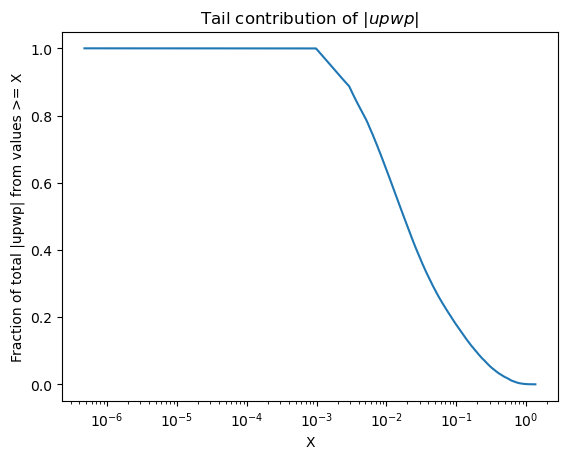

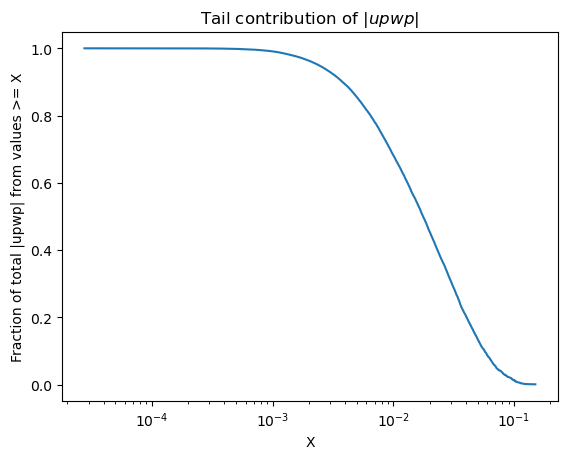

In [5]:
%%time
#################################################################
# Make event lists ... and composites
importlib.reload(euti)
importlib.reload(auti)

zlev_event=15_000. #23_000.
lat_range=  [-50,-40] #[-70,-60] #[-60,-40]
lat_range=  [-60,-40] #[-70,-60] #[-60,-40]
#lat_range=  [35,65] # Northern Summer!!!!!!!!!!
lon_range=[0,360] # [0,60]
exclude_orography=True

fracs=[0.995,0.90,0.50,0.25,0.125,0.0625]
#fracs=[0.95,0.90,0.50,0.25,0.125,0.0625]

El = euti.make_El(
            A=A, 
            fractions_for_thresholds=fracs,
            zlev_event=zlev_event, 
            lat_range=lat_range,
            lon_range=lon_range,
            exclude_orography= exclude_orography,
            peak_footprint=(3,3),
            return_after_stage1=False
           )




In [6]:
print(A.epwp.shape)
print( A.epwp.shape[0] * A.epwp.shape[2] * A.epwp.shape[3] )


(247, 58, 53, 288)
3770208


[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]
[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]
[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]


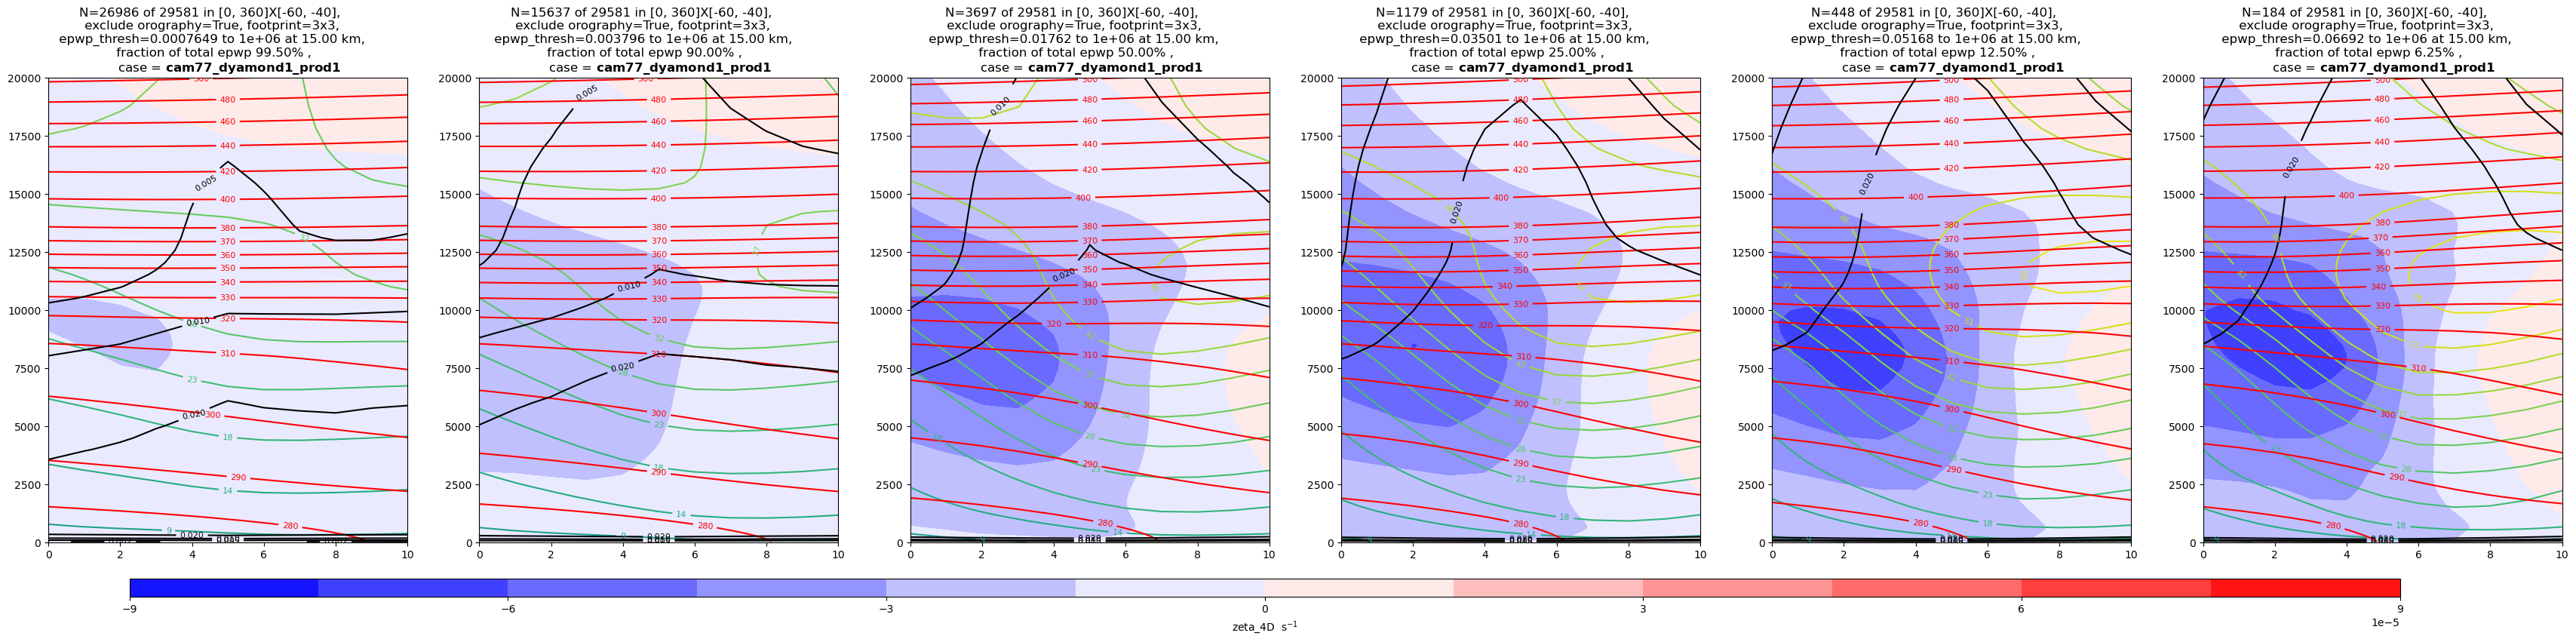

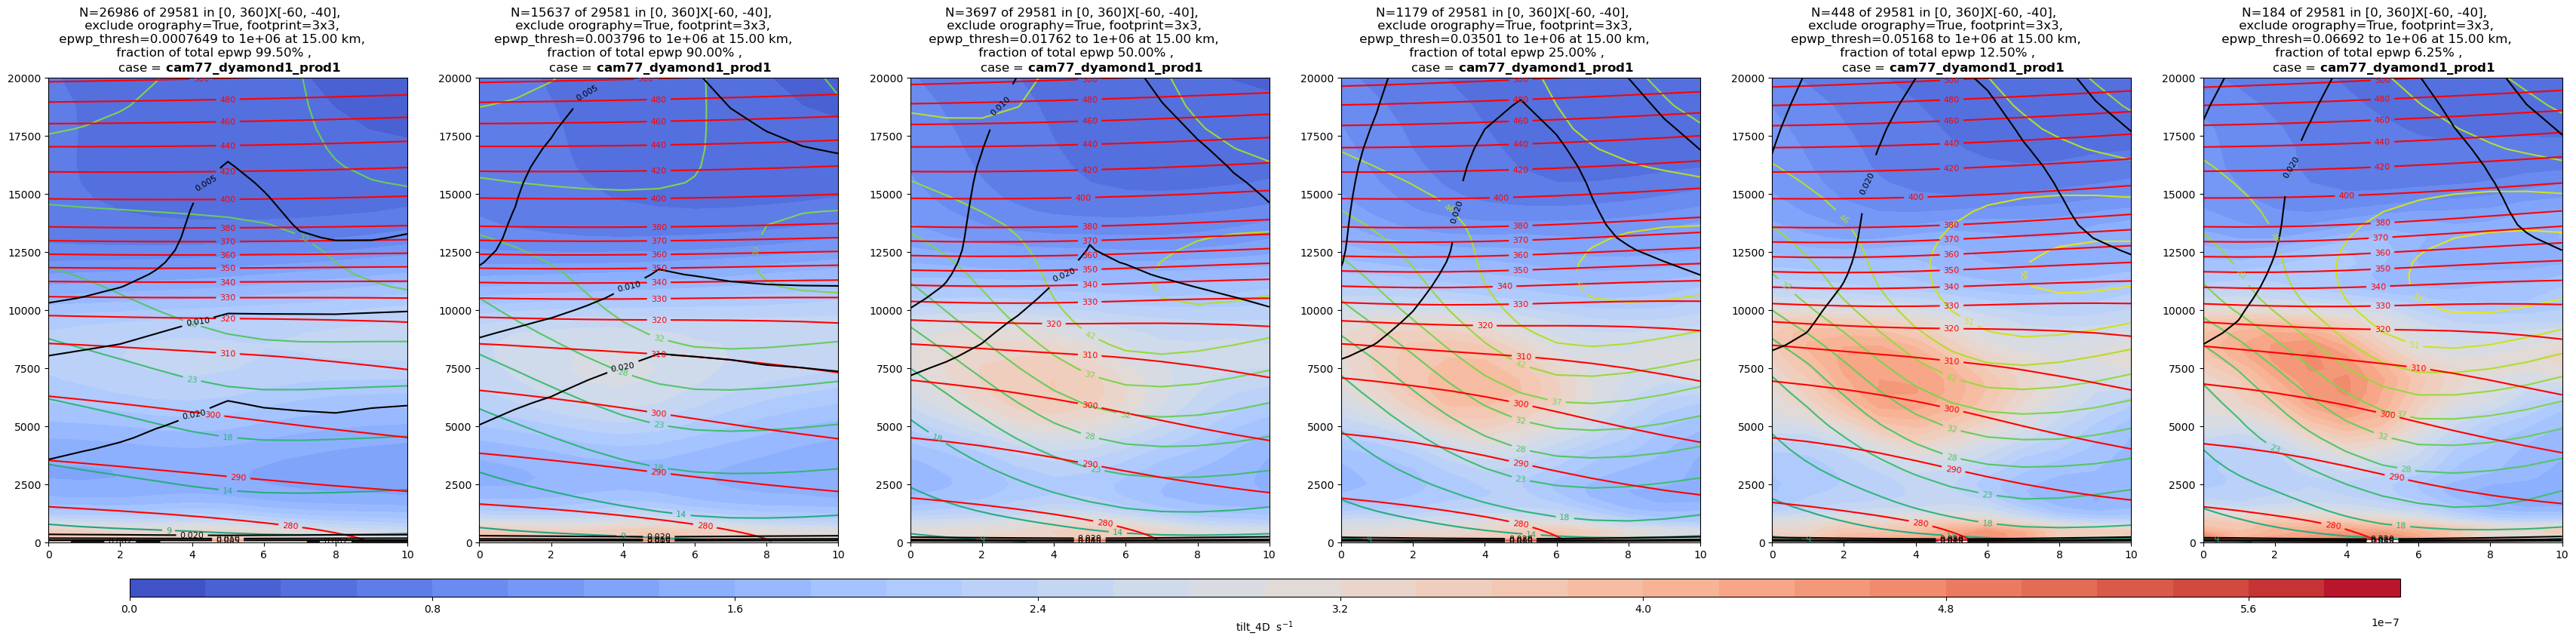

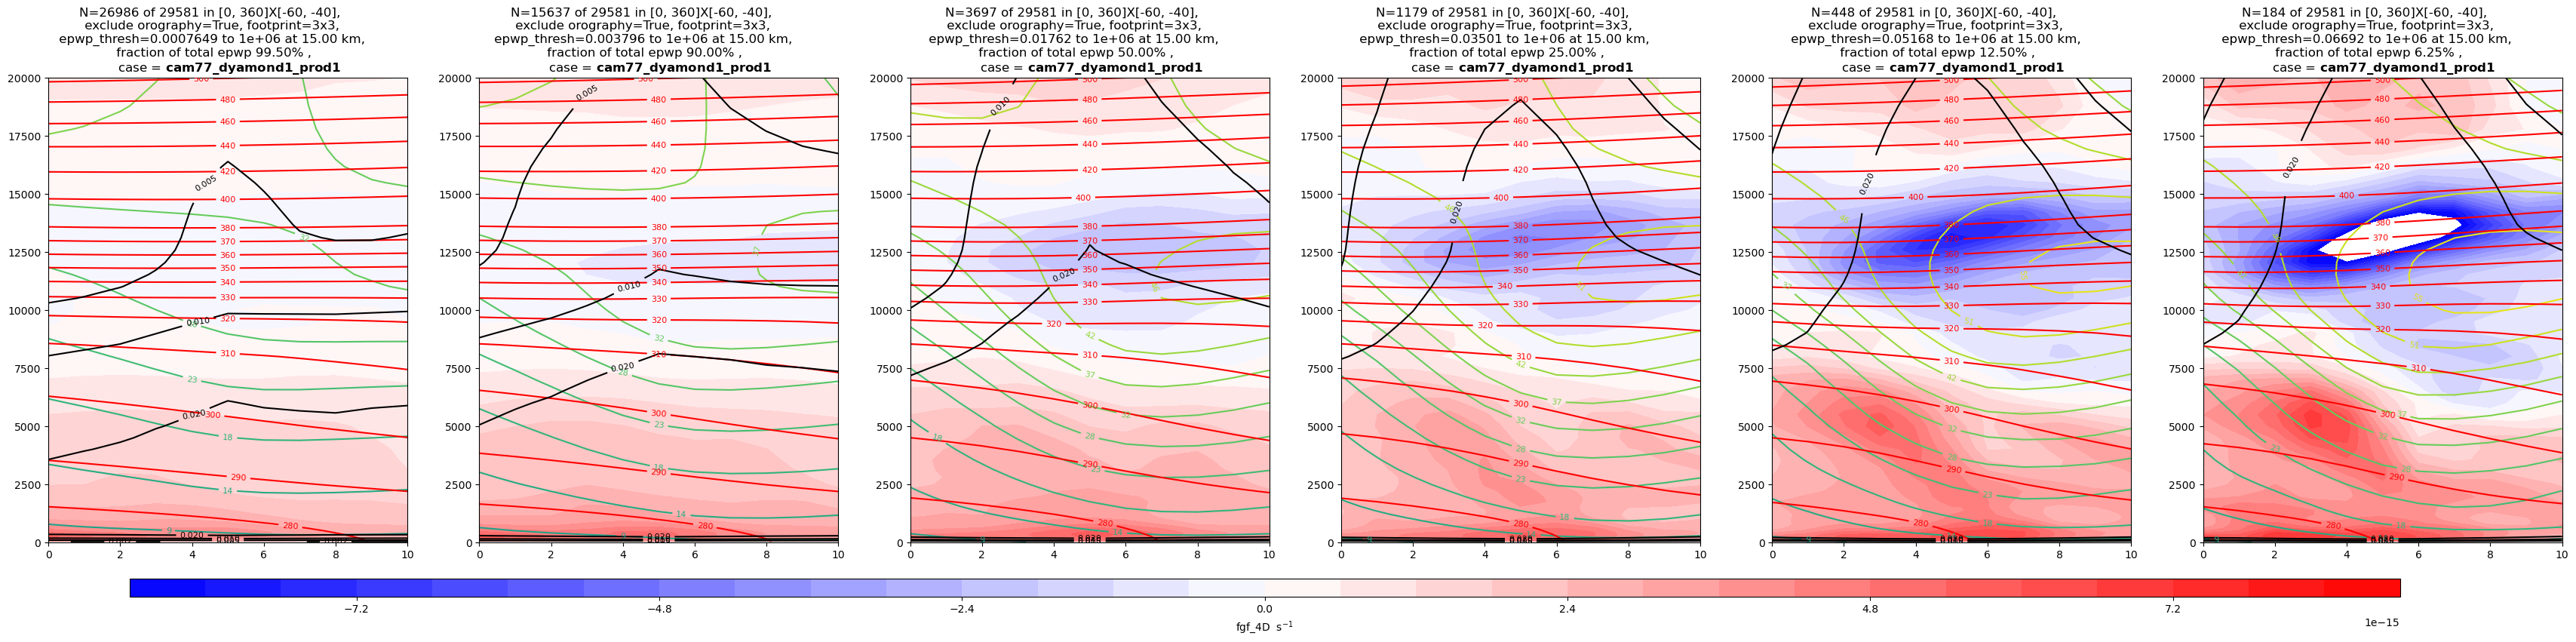

In [7]:
importlib.reload( auti )
auti.plot_xavg_compos( fld='zeta_4D', El=El )
auti.plot_xavg_compos( fld='tilt_4D', El=El )
auti.plot_xavg_compos( fld='fgf_4D', El=El )


In [8]:

ds=El[0].ds
print(int(ds.itime.values.max()) + 1)

ds_drop=ds.drop_vars( ['lat','lon','zlev'] )


event_list=euti.ds_to_event_list( ds_drop )

247
Reconstructed 26986 events across 247 timesteps
  0 timesteps had no events


In [9]:
evoo=event_list[120]
len(evoo)
np.array(evoo[1]['ix'])

array(214)

In [10]:
import random_forest as RF

Eco=   El[0]  #euti.combine_event_dicts(El[3], El[1], label_key='event_strength')

In [11]:
Eco.zeta_4D.shape

(26986, 4, 58, 11, 11)

In [12]:
#### SAVE OFF events dataset
_t=0
euti.write_ds(ds=El[_t].ds, A=A,fraction_of_total=El[_t].Frac_of_total_epwp,
            zlev_event=zlev_event,thresh=El[_t].threshold,
            lat_range=lat_range,lon_range=lon_range,extra_info='_NoTopo' )


writing cam77_dyamond1_prod1_f99.5%epwpEvents_Z15km_2016-08-01-10800-2016-08-31-75600_60S-40S_NoTopo.nc


(26986, 4, 58, 11, 11)
(26986,)
Patch mean zeta vs patch mean epwp: r=-0.105, p=5.32e-67
Patch mean tilt vs patch mean epwp: r=0.500, p=0.00e+00
Patch mean fgf vs patch mean epwp: r=0.094, p=3.27e-54


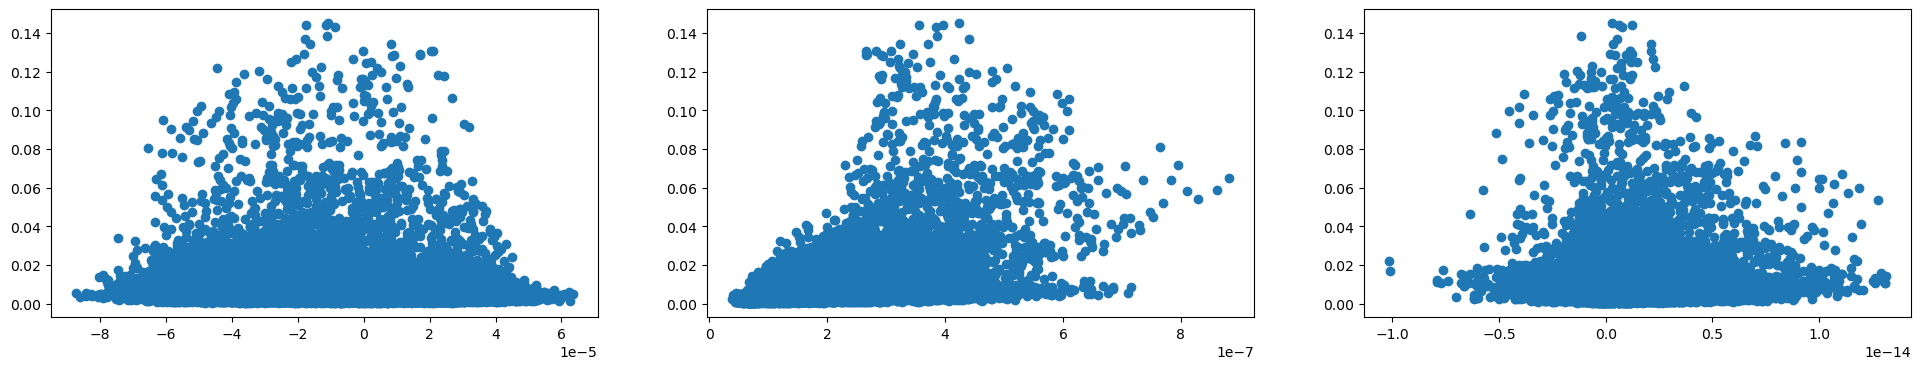

In [13]:
from scipy import stats

z0=np.argmin( np.abs( zlev-0.))
z3=np.argmin( np.abs( zlev-3000.))
z5=np.argmin( np.abs( zlev-5000.))
z6=np.argmin( np.abs( zlev-6000.))
z7=np.argmin( np.abs( zlev-7000.))
z10=np.argmin( np.abs( zlev-10000.))
z11=np.argmin( np.abs( zlev-11000.))
z12=np.argmin( np.abs( zlev-12000.))
z15=np.argmin( np.abs( zlev-15000.))
print(Eco.epwp_4D.shape)

#xv=Eco.zeta_4D[:,1,z6,4,:].mean(axis=1)
#xv=np.mean(Eco.zeta_4D[:,:,z10,4,:],axis=(1,2))
#xv=np.mean(Eco.zeta_4D[:,:,z7,:,:],axis=(1,2,3))
#xv=np.mean( Eco.tilt_4D[:,:,z7,:,:],axis=(1,2,3)  ) 

xvs=[]
xvs.append( np.mean( Eco.zeta_4D[:,:,z10:z3,:,:],axis=(1,2,3,4)  ) )
xvs.append( np.mean( Eco.tilt_4D[:,:,z10:z3,:,:],axis=(1,2,3,4)  ) )
xvs.append( np.mean( Eco.fgf_4D[:,:,z10:z3,:,:],axis=(1,2,3,4)  ) )
flds=['zeta','tilt','fgf']

yv=np.mean( Eco.epwp_4D[:,:,z10,:,:],axis=(3,2,1) )
#yv=np.mean( Eco.epwp_4D[:,nt_v-1,z10,:,:],axis=(2,1) )
print(yv.shape)

fig,axs=plt.subplots( 1, len(xvs), figsize=( (len(xvs)*8, 4 ) ) )
ip=0
for xv in xvs:
    ax=axs[ip]
    ax.scatter( xv,yv )
    r, p = stats.pearsonr(xv, yv)
    print(f"Patch mean {flds[ip]} vs patch mean epwp: r={r:.3f}, p={p:.2e}")
    ip=ip+1


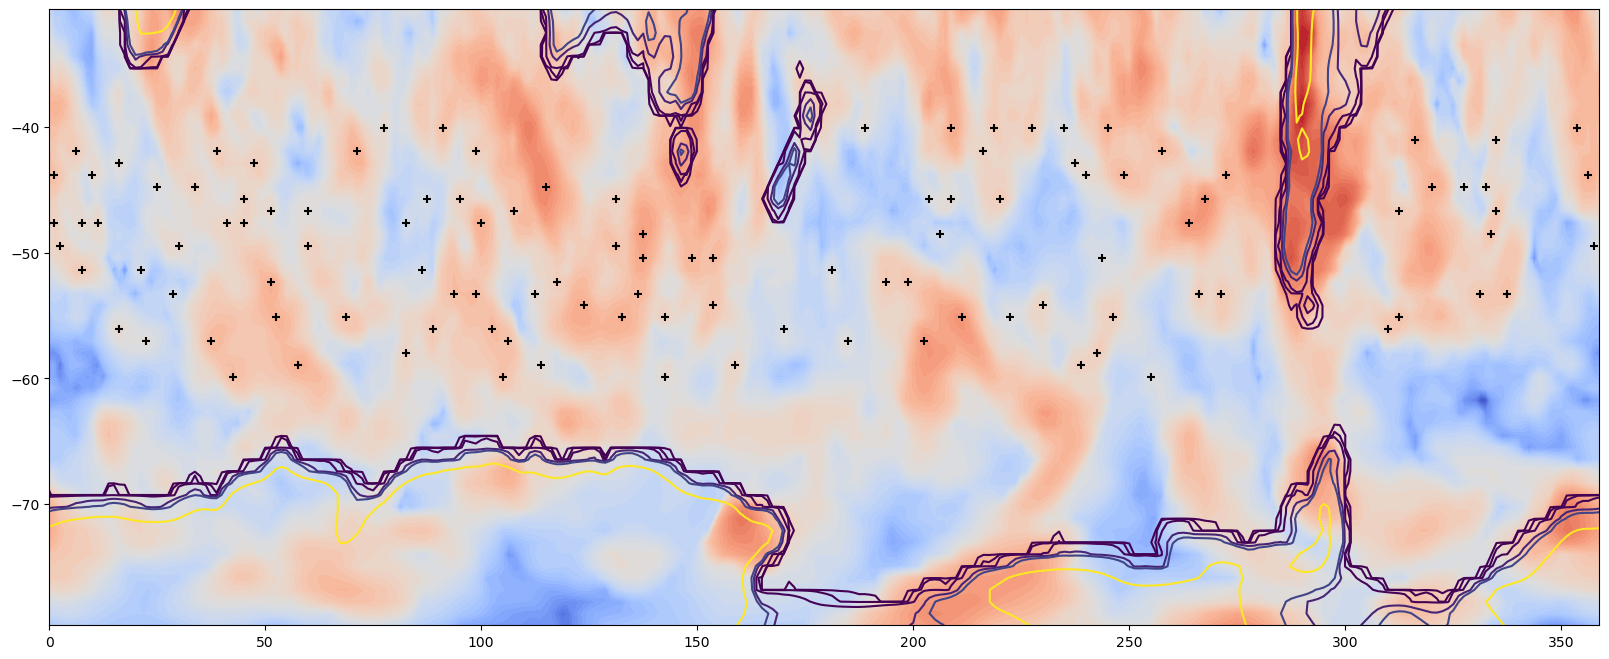

In [14]:
evoo=event_list[120]
fig,ax=plt.subplots( figsize=(20,8) )
ax.contourf(lon,lat,np.log(A.rho_epwp[120,z15,:,:]), levels=51, cmap='coolwarm')
for ev in evoo:
    ax.scatter( lon[ev['ix']] , lat[ev['iy']], marker='+' , c='black')
ax.contour( lon, lat, A.htopo , levels=[0.1,1,10,100,200,1000] )

Predictors = ['u_4D', 'v_4D', 'tilt_4D', 'zeta_4D']
key_z levels (m) = [510, 1064, 3144, 4994, 5994, 6994, 9996, 11012, 12045, 14836]
n_predictors = 160
target scaled by 1.0
Events in cam77_dyamond1_prod1,latlon=[0, 360]X[-60, -40], exclude orography=True 
Peak footprint=(3, 3)
Dates 2016-08-01-10800 to 2016-08-31-75600, nsteps=247, stepsize=3 hrs


Feature matrix : 26986 events x 160 predictors
Target (raw)   : mean=0.0052  std=0.0060
Target (log)   : mean=-5.678  std=0.906  device=cpu
Interval split : 21726 train, 3075 test
Log-transforming 40 predictor(s) matching ['tilt']
log(y) train   : mean=-5.690  std=0.922  → normalised to mean≈0  std≈1
Loss           : |error|^5.0
  Epoch  25  val_loss=0.3627  lr=6.25e-05
  Epoch  50  val_loss=0.3506  lr=1.00e-06
  Epoch  75  val_loss=0.3538  lr=1.00e-06
  Epoch 100  val_loss=0.3539  lr=1.00e-06
  Early stop epoch 108  best_val_loss=0.3391  lr=1.00e-06
Train R²:  0.736
Test  R²:  0.555
Test  r:   0.767  (p=0.00e+00)
Computing permutation impo

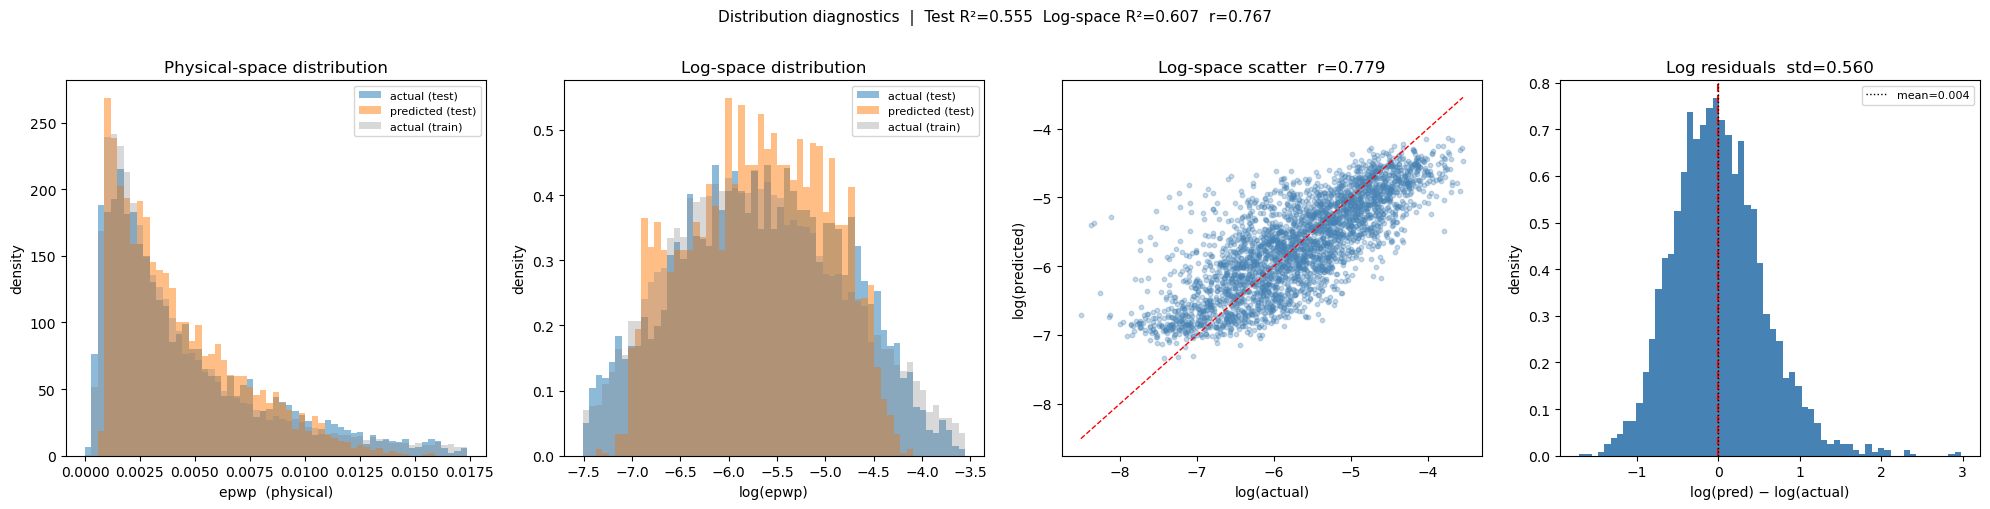

'\n\n\n# fit\nrf, results = RF.fit_rf_general(predictors=predictors, \n                                   predictor_names=predictor_names, \n                                   target=yv,\n                                   event_times = Eco.time4D ,\n                                   train_interval   = (48,248),\n                                   test_interval    = (0,28),\n                                   min_samples_leaf=10,\n                                    )\n\nRF.plot_rf_results(results, top_n=20)\n'

In [20]:
import importlib                                                                                                                                                                                                                                                                                              
import mlp_utils as mlu                                                                                                                                                                                                                                                                                       
importlib.reload(mlu) 
importlib.reload(RF)


nv,nt_v,nz_v,ny_v,nx_v = np.shape( Eco.zeta_4D )

z0=np.argmin( np.abs( zlev-0.))
z0p5=np.argmin( np.abs( zlev-500))
z1=np.argmin( np.abs( zlev-1000.))
z3=np.argmin( np.abs( zlev-3000.))
z5=np.argmin( np.abs( zlev-5000.))
z6=np.argmin( np.abs( zlev-6000.))
z7=np.argmin( np.abs( zlev-7000.))
z10=np.argmin( np.abs( zlev-10000.))
z11=np.argmin( np.abs( zlev-11000.))
z12=np.argmin( np.abs( zlev-12000.))
z15=np.argmin( np.abs( zlev-15000.))

predictors=[]
predictor_names=[]

pred_scaling=1.
targ_scaling=1.
# use_predictors=['u_4D','v_4D','tilt_4D']
use_predictors = ['u_4D', 'v_4D', 'tilt_4D', 'zeta_4D']
#use_predictors = ['u_4D', 'v_4D', 'fgf_4D', 'zeta_4D']

key_z = [z0p5, z1, z3, z5, z6, z7, z10, z11, z12, z15]
#key_z = [z0p5, z1, z3, z5, z6, z7, z10]
for t in np.arange(nt_v):
    for z in key_z:
        for prd in use_predictors:
            predictors.append(np.mean(Eco[prd][:,t,z,0:6,:], axis=(1,2)))
            predictor_names.append(f"{prd} t={t-nt_v+1}, z={zlev[z]:.0f}")

yv=targ_scaling*np.mean( Eco.epwp_4D[:,-1,z12,:,:],axis=(2,1) )

print( f"Predictors = {use_predictors}" )
print( f"key_z levels (m) = {[int(zlev[z]) for z in key_z]}" )
print( f"n_predictors = {len(predictors)}" )
print(f"target scaled by {targ_scaling}")
print( f"Events in {Eco.case},latlon={Eco.lon_range}X{Eco.lat_range}, exclude orography={Eco.exclude_orography} " )
print( f"Peak footprint={Eco.peak_footprint}" )
print( f"Dates {A.start_date} to {A.end_date}, nsteps={A.nsteps}, stepsize={A.step_size} hrs" )
print( '\n' )

mlp_model, mlp_results = mlu.fit_mlp_general(
    predictors       = predictors,        # same list already built above
    predictor_names  = predictor_names,
    target           = yv,
    event_times      = Eco.time4D,
    train_interval   = (48, 248),         # same split as the RF
    test_interval    = (0, 28),
    dropout=0.1,
    hidden_dims      = (256, 256, 256, 128),
    weight_decay     = 1e-5,
    patience         = 100,
    lr_patience      = 3,
    batch_size=512,
    loss_power = 5,
    log_predictor_patterns = ['tilt'],)   # <-- new )

mlu.plot_distributions(mlp_results)   # <-- the new diagnostic  




"""


# fit
rf, results = RF.fit_rf_general(predictors=predictors, 
                                   predictor_names=predictor_names, 
                                   target=yv,
                                   event_times = Eco.time4D ,
                                   train_interval   = (48,248),
                                   test_interval    = (0,28),
                                   min_samples_leaf=10,
                                    )

RF.plot_rf_results(results, top_n=20)
"""


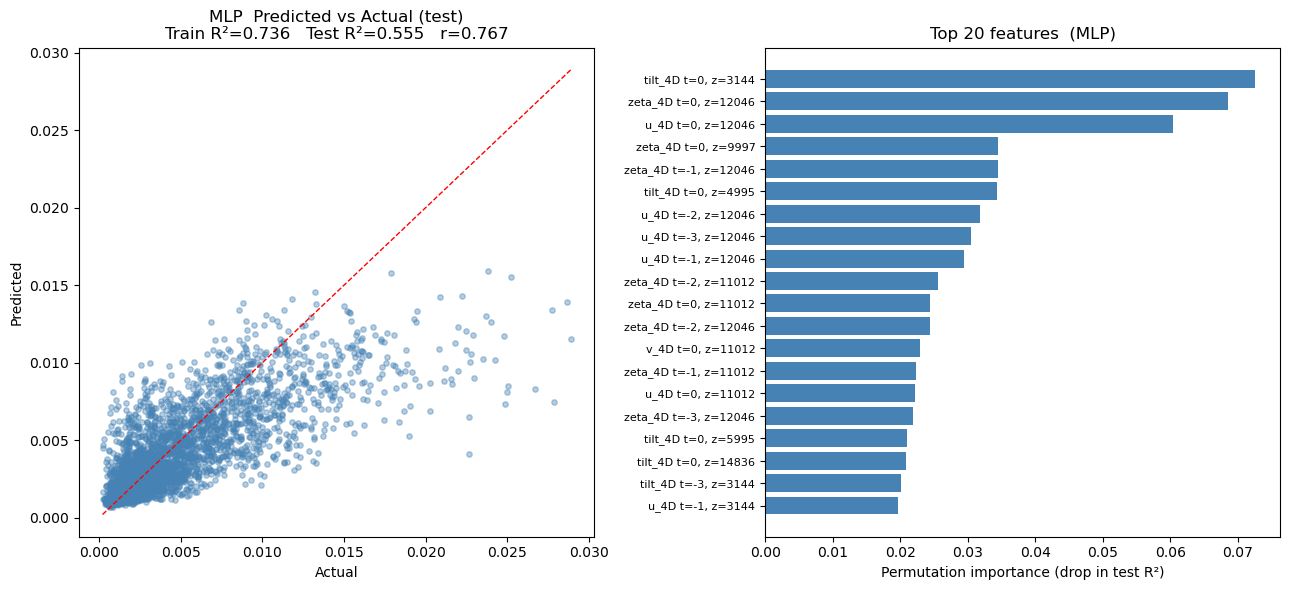

In [21]:
mlu.plot_mlp_results(mlp_results, top_n=20)

In [17]:
print(poopypants)

NameError: name 'poopypants' is not defined

In [ ]:

importlib.reload(mlu)
mlp_model, mlp_results = mlu.fit_mlp_general(
    predictors       = predictors,        # same list already built above
    predictor_names  = predictor_names,
    target           = yv,
    event_times      = Eco.time4D,
    train_interval   = (48, 248),         # same split as the RF
    test_interval    = (0, 28),
    dropout=0.1,
    hidden_dims      = (256, 256, 256, 128),
    weight_decay     = 1e-5,
    patience         = 100,
    lr_patience      = 3,
    batch_size=512,
    loss_power = 5,
    log_predictor_patterns = ['zeta'],)   # <-- new )

mlu.plot_distributions(mlp_results)   # <-- the new diagnostic  

In [ ]:
mlu.plot_predictor_distributions(mlp_results)